--- K-Means Clustering for Learning Styles ---

Cluster Centroids (Mean Preference for each VARK style in each cluster):
            Preferred_Learning_Style_Visual  Preferred_Learning_Style_Aural  \
Cluster ID                                                                    
0                                      0.33                             1.0   
1                                      0.50                             0.0   
2                                      1.00                             1.0   
3                                      1.00                             0.0   

            Preferred_Learning_Style_ReadWrite  \
Cluster ID                                       
0                                          0.0   
1                                          1.0   
2                                          1.0   
3                                          0.0   

            Preferred_Learning_Style_Kinesthetic  
Cluster ID                                        
0

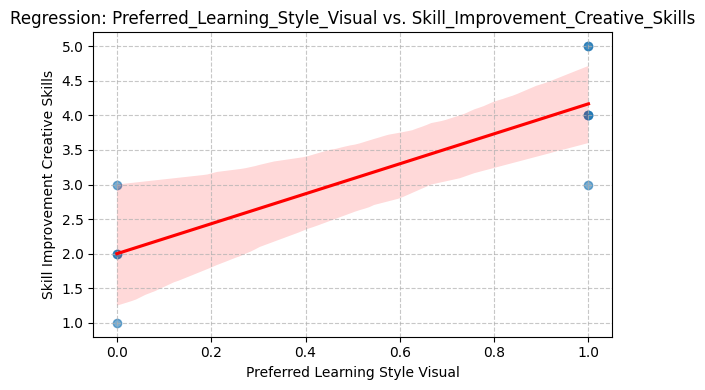


--- Hypothesis 2: Read/Write Preference vs. Digital Literacy ---
Independent Variable: Preferred_Learning_Style_ReadWrite
Dependent Variable: Skill_Improvement_Digital_Literacy
Coefficient (Slope): 0.750
Intercept: 3.250
Root Mean Squared Error (RMSE): 1.037
R-squared (R2): 0.112

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Digital_Literacy' changes for a one-unit increase in 'Preferred_Learning_Style_ReadWrite'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Digital_Literacy' that can be predicted from 'Preferred_Learning_Style_ReadWrite'. A higher R2 (closer to 1) suggests a better fit.
- A positive coefficient suggests that as 'Preferred_Learning_Style_ReadWrite' increases (i.e., preference for this style is higher), 'Skill_Improvement_Digital_Literacy' also tends to increase (i.e., skill improvement is higher).


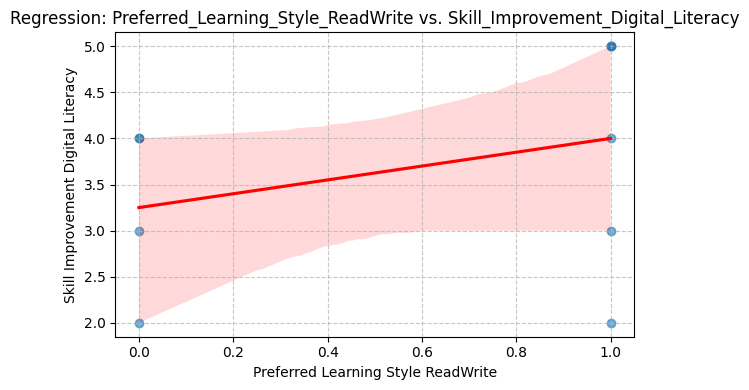


--- Hypothesis 3: Kinesthetic Preference vs. Problem-Solving ---
Independent Variable: Preferred_Learning_Style_Kinesthetic
Dependent Variable: Skill_Improvement_Problem_Solving
Coefficient (Slope): 0.200
Intercept: 3.800
Root Mean Squared Error (RMSE): 1.039
R-squared (R2): 0.009

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Problem_Solving' changes for a one-unit increase in 'Preferred_Learning_Style_Kinesthetic'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Problem_Solving' that can be predicted from 'Preferred_Learning_Style_Kinesthetic'. A higher R2 (closer to 1) suggests a better fit.
- A positive coefficient suggests that as 'Preferred_Learning_Style_Kinesthetic' increases (i.e., preference for this style is higher), 'Skill_Improvement_Problem_Solving' also tends to increase (i.e., skill improvement is higher).


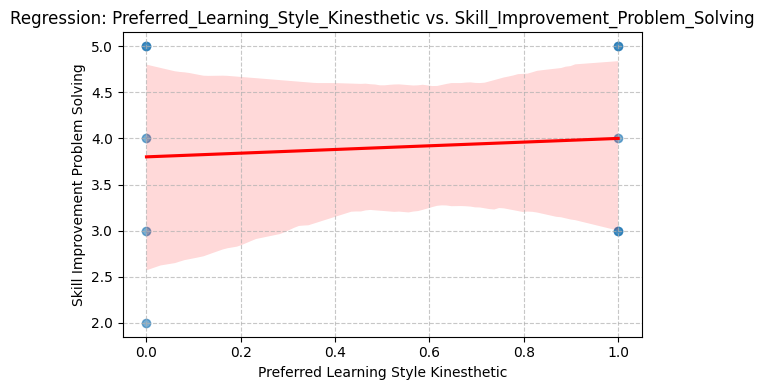


--- End of Data Analysis Algorithms ---


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from io import StringIO

# Data Analysis Algorithms
# The preprocessed data were analyzed using two key machine learning algorithms to uncover patterns and interconnections:

# --- Data Loading (Simulated from previous CSV structure) ---
csv_data = """Participant_ID,Overall_Ease_of_Use,Multimodal_Feature_Effectiveness,Preferred_Learning_Style_Visual,Preferred_Learning_Style_Aural,Preferred_Learning_Style_ReadWrite,Preferred_Learning_Style_Kinesthetic,Platform_Performance,Influence_of_Content_Creation,Skill_Improvement_Digital_Literacy,Skill_Improvement_Problem_Solving,Skill_Improvement_Creative_Skills,Adaptability_to_Learning_Style,Advantage_over_Traditional_LMS,Satisfaction_with_Current_Features,Overall_Value,Additional_Comments
1,4,5,1,0,1,0,5,4,4,5,4,4,4,3,5,"The visual diagrams are incredibly helpful, but I wish there were more interactive quizzes."
2,3,3,0,1,0,1,3,2,3,3,2,3,2,2,3,"The platform is slow on my old tablet. Audio narration is good, but content creation was confusing."
3,5,5,1,1,1,1,5,5,5,5,5,5,5,4,5,"Absolutely love this platform! It caters to all my learning needs and I feel my problem-solving skills have significantly improved."
4,2,3,0,0,1,0,2,2,2,3,2,2,1,1,2,"Too much reading, not enough hands-on activities. It's hard to navigate on my phone."
5,4,4,1,0,0,1,4,3,4,4,3,4,3,3,4,"The kinesthetic exercises are great. I'd like to see more integration with external tools."
6,5,4,1,0,1,0,5,4,5,4,4,4,4,3,5,"Very intuitive interface. Content creation really solidified my understanding. No major complaints."
7,3,2,0,1,0,0,3,1,2,2,1,2,2,2,2,"The text-to-speech is robotic. I don't feel like the platform adapted to how I learn at all."
8,4,5,1,1,0,0,4,4,4,5,4,5,4,4,5,"Excellent multimodal features, especially the visual aids. My digital literacy definitely improved."
9,3,3,0,0,1,1,3,3,3,3,3,3,3,3,3,"It's okay, but nothing revolutionary. Some features are good, others are just average."
10,5,5,1,1,1,1,5,5,5,5,5,5,5,5,5,"This is the best learning platform I've ever used. Every feature is top-notch and truly enhances learning. No changes needed!"
"""
df = pd.read_csv(StringIO(csv_data))

# --- K-Means Clustering ---

print("--- K-Means Clustering for Learning Styles ---")

# Select features for K-Means Clustering (VARK preferences)
vark_features = [
    'Preferred_Learning_Style_Visual',
    'Preferred_Learning_Style_Aural',
    'Preferred_Learning_Style_ReadWrite',
    'Preferred_Learning_Style_Kinesthetic'
]

X_vark = df[vark_features]

# Determine the number of clusters (k)
# For demonstration, we'll choose k=4, assuming we want to broadly align with VARK types
# In a real scenario, you might use the Elbow Method or domain knowledge to choose k.
chosen_k = 4
if len(X_vark) < chosen_k:
    print(f"Warning: Number of samples ({len(X_vark)}) is less than chosen_k ({chosen_k}). Adjusting k to {len(X_vark)}.")
    chosen_k = len(X_vark)
    if chosen_k == 0:
        print("No data to cluster.")
    elif chosen_k == 1:
        print("Only one sample, no clustering possible. Assigning to a single cluster.")
        df['VARK_Cluster'] = 0 # Assign to a single cluster
    else: # For 2 or 3 samples, K-Means might still run but interpretation is limited
        kmeans_model = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
        df['VARK_Cluster'] = kmeans_model.fit_predict(X_vark)
else:
    kmeans_model = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
    df['VARK_Cluster'] = kmeans_model.fit_predict(X_vark)

# Interpret Clusters
if chosen_k > 1: # Only interpret if actual clustering happened
    cluster_centers = kmeans_model.cluster_centers_
    cluster_centers_df = pd.DataFrame(cluster_centers, columns=vark_features).round(2)
    cluster_centers_df.index.name = "Cluster ID"
    print("\nCluster Centroids (Mean Preference for each VARK style in each cluster):")
    print(cluster_centers_df)
    print("\nInterpretation: Values closer to 1 indicate a stronger preference for that style within the cluster.")
    print("For example, if Cluster 0 has [0.9, 0.1, 0.8, 0.2], it suggests a strong Visual and Read/Write preference.")
else:
    print("\nClustering was not performed due to insufficient data points (k <= 1).")

print("\nNumber of Participants per Cluster:")
print(df['VARK_Cluster'].value_counts().sort_index())

# --- Linear Regression ---

print("\n--- Linear Regression for Hypothesis Testing ---")

# Define example hypotheses based on questionnaire fields
# Hypothesis 1: Does Visual learning preference correlate with Creative Skills Improvement?
independent_var_1 = 'Preferred_Learning_Style_Visual'
dependent_var_1 = 'Skill_Improvement_Creative_Skills'

# Hypothesis 2: Does Read/Write learning preference correlate with Digital Literacy Improvement?
independent_var_2 = 'Preferred_Learning_Style_ReadWrite'
dependent_var_2 = 'Skill_Improvement_Digital_Literacy'

# Hypothesis 3: Does Kinesthetic learning preference correlate with Problem-Solving Improvement?
independent_var_3 = 'Preferred_Learning_Style_Kinesthetic'
dependent_var_3 = 'Skill_Improvement_Problem_Solving'

hypotheses = [
    (independent_var_1, dependent_var_1, "Visual Preference vs. Creative Skills"),
    (independent_var_2, dependent_var_2, "Read/Write Preference vs. Digital Literacy"),
    (independent_var_3, dependent_var_3, "Kinesthetic Preference vs. Problem-Solving")
]

for i, (ind_var, dep_var, hypothesis_name) in enumerate(hypotheses):
    print(f"\n--- Hypothesis {i+1}: {hypothesis_name} ---")

    # Prepare data
    X = df[[ind_var]] # Independent variable (needs to be 2D array)
    y = df[dep_var]   # Dependent variable

    # Split data into training and testing sets (optional for small datasets, but good practice)
    # For very small datasets, cross-validation might be more appropriate than train/test split.
    # Here, we'll fit on the full data for simplicity given the small sample.
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create and train the model
    model_lr = LinearRegression()
    model_lr.fit(X, y) # Fitting on full data

    # Make predictions (on the same data for demonstration)
    y_pred = model_lr.predict(X)

    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)

    print(f"Independent Variable: {ind_var}")
    print(f"Dependent Variable: {dep_var}")
    print(f"Coefficient (Slope): {model_lr.coef_[0]:.3f}")
    print(f"Intercept: {model_lr.intercept_:.3f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
    print(f"R-squared (R2): {r2:.3f}")

    # Interpretation Guidance
    print("\nInterpretation:")
    print(f"- The coefficient indicates how much the '{dep_var}' changes for a one-unit increase in '{ind_var}'.")
    print(f"- R-squared (R2) represents the proportion of variance in '{dep_var}' that can be predicted from '{ind_var}'. A higher R2 (closer to 1) suggests a better fit.")
    if model_lr.coef_[0] > 0:
        print(f"- A positive coefficient suggests that as '{ind_var}' increases (i.e., preference for this style is higher), '{dep_var}' also tends to increase (i.e., skill improvement is higher).")
    else:
        print(f"- A negative coefficient suggests that as '{ind_var}' increases, '{dep_var}' tends to decrease.")

    # Visualize the regression (optional)
    plt.figure(figsize=(6, 4))
    sns.regplot(x=df[ind_var], y=df[dep_var], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'Regression: {ind_var} vs. {dep_var}')
    plt.xlabel(ind_var.replace('_', ' '))
    plt.ylabel(dep_var.replace('_', ' '))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("\n--- End of Data Analysis Algorithms ---")